# **Inicialización del Proyecto — PhraseNet-AR (Autoregressive)**
En esta nueva versión construiremos un modelo generador de frases basado en un **decoder autoregresivo**, similar en concepto a GPT, pero mucho más ligero y diseñado para SynkroHogar.

¿Por qué un modelo autoregresivo?

1. Porque genera la frase **token por token**, usando el token anterior como entrada.
2. Porque aprende estructuras de lenguaje reales.
3. Porque resuelve el problema de underfitting del modelo anterior.
4. Porque permite generalizar frases nuevas, no solo memorizar patrones.

Antes de construir el modelo, cargaremos el dataset `frases_10000.csv` y verificaremos su estructura.


In [1]:
import pandas as pd

df = pd.read_csv("frases_10000.csv")

print("Total filas:", len(df))
display(df.head())
print(df["comando"].value_counts())


Total filas: 10000


,comando,texto
0,siguienteMelodia,Reproducción secuencial siguiente
1,modoNormal,Volviendo al estado original
2,modoSuper,Modo super confirmado
3,modoSuper,Funciones super implementadas
4,encenderLuces,Sistema en modo iluminado


comando
encenderLuces       1499
modoSuper           1471
modoNormal          1441
siguienteMelodia    1434
abrirPuerta         1406
apagarLuces         1376
anteriorMelodia     1373
Name: count, dtype: int64


# **Preparación del Corpus y Tokenización con SentencePiece**
El modelo autoregresivo necesitará trabajar con texto tokenizado.

En esta etapa:

1. Construimos el archivo `corpus.txt` con **todas las frases del dataset**.
2. Entrenamos SentencePiece con un vocabulario de 600 piezas.
3. Cargamos el tokenizer resultante:
   - `tok.model`
   - `tok.vocab`

Este tokenizer generará secuencias apropiadas para el decoder.


In [2]:
import sentencepiece as spm

with open("corpus.txt", "w", encoding="utf-8") as f:
    for t in df["texto"].tolist():
        f.write(str(t) + "\n")

spm.SentencePieceTrainer.Train(
    '--input=corpus.txt --model_prefix=tok --vocab_size=600 --character_coverage=1.0'
)

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load("tok.model")

print("Tokenizer cargado. Vocab size:", tokenizer.GetPieceSize())


Tokenizer cargado. Vocab size: 600


# **Construcción del Dataset Autoregresivo**
A diferencia del modelo anterior, ahora usaremos:

- **Teacher Forcing**
- **Entrada desplazada (tokens_in)**
- **Salida objetivo (tokens_out)**

Formato:

Entrada:
<bos> Abriendo puerta principal

Salida:
Abriendo puerta principal <eos>

El comando se usará como **token especial agregado al inicio** para guiar la frase generada.


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

bos = tokenizer.bos_id() if tokenizer.bos_id() != -1 else 1
eos = tokenizer.eos_id() if tokenizer.eos_id() != -1 else 2
pad = 0

comandos = sorted(df["comando"].unique())
cmd2id = {c:i for i,c in enumerate(comandos)}
id2cmd = {i:c for c,i in cmd2id.items()}

max_len = 20

class PhraseDatasetAR(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df
        self.tok = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        texto = fila.texto
        cmd = fila.comando

        tokens = self.tok.encode(texto, out_type=int)
        tokens = [bos] + tokens + [eos]
        tokens = tokens[:max_len]

        tokens_in = tokens[:-1]
        tokens_out = tokens[1:]

        tokens_in += [pad]*(max_len - len(tokens_in))
        tokens_out += [pad]*(max_len - len(tokens_out))

        cmd_id = cmd2id[cmd]

        return torch.tensor(cmd_id), torch.tensor(tokens_in), torch.tensor(tokens_out)

dataset = PhraseDatasetAR(df, tokenizer)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Dataset autoregresivo listo.")


Dataset autoregresivo listo.


# **Definición del Modelo PhraseNet-AR (Decoder Autoregresivo)**
El modelo estará compuesto por:

1. Embedding del comando
2. Embedding de tokens de entrada
3. Suma de embeddings + posición
4. GRU decoder autoregresivo
5. Capa final a vocabulario

Este modelo sí aprende lenguaje real y puede generar frases nuevas.


In [4]:
import torch.nn as nn
import math

class PhraseNetAR(nn.Module):
    def __init__(self, num_cmds, vocab_size, emb_dim=128, hidden_dim=256):
        super().__init__()

        self.emb_cmd = nn.Embedding(num_cmds, emb_dim)
        self.emb_tok = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, cmd_ids, tokens_in):
        batch = cmd_ids.size(0)
        seq_len = tokens_in.size(1)

        cmd_embedding = self.emb_cmd(cmd_ids).unsqueeze(1)
        cmd_embedding = cmd_embedding.repeat(1, seq_len, 1)

        tok_embedding = self.emb_tok(tokens_in)

        pos_ids = torch.arange(seq_len).unsqueeze(0).to(tokens_in.device)
        pos_embedding = self.pos_emb(pos_ids)

        x = tok_embedding + cmd_embedding + pos_embedding

        out, _ = self.gru(x)
        logits = self.fc(out)

        return logits

num_cmds = len(cmd2id)
vocab_size = tokenizer.GetPieceSize()

model = PhraseNetAR(num_cmds, vocab_size).cuda()

print("Modelo autoregresivo listo.")


Modelo autoregresivo listo.


## **Entrenamiento Autoregresivo con Teacher Forcing, Scheduler y Early Stopping**

En esta sección entrenaremos el modelo PhraseNet-AR aplicando técnicas modernas para estabilizar y acelerar el aprendizaje:

### 1. Teacher Forcing
En cada paso el modelo recibe:

- `tokens_in`: secuencia desplazada (<bos>, palabra1, palabra2…)
- `tokens_out`: salida objetivo (palabra1, palabra2…, <eos>)

Esto permite que el modelo aprenda relaciones reales entre tokens.

### 2. Accuracy por token
Se calcula comparando cada token predicho con el token real.  
Mientras el modelo aprende, el accuracy debe subir y la pérdida debe bajar.

### 3. Learning Rate Scheduler
Usamos `ReduceLROnPlateau`, que reduce el LR automáticamente cuando no hay mejora en la pérdida.

### 4. Early Stopping
Si la pérdida deja de mejorar por varias épocas seguidas, el entrenamiento se detendrá automáticamente para evitar desperdiciar tiempo y evitar sobreajuste.

Con estas técnicas, PhraseNet-AR debería converger a pérdidas alrededor de **0.5 – 1.0** y accuracies superiores a **0.80**.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import os

save_dir = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\modelos\PhraseNet_AR"
os.makedirs(save_dir, exist_ok=True)

class PhraseNetAR(nn.Module):
    def __init__(self, num_cmds, vocab_size, emb_dim=128, hidden_dim=256, max_len=64):
        super().__init__()

        self.emb_cmd = nn.Embedding(num_cmds, emb_dim)
        self.emb_tok = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, cmd_ids, tokens_in):
        batch = cmd_ids.size(0)
        seq_len = tokens_in.size(1)

        cmd_embedding = self.emb_cmd(cmd_ids).unsqueeze(1)
        cmd_embedding = cmd_embedding.repeat(1, seq_len, 1)

        tok_embedding = self.emb_tok(tokens_in)

        pos_ids = torch.arange(seq_len).unsqueeze(0).to(tokens_in.device)
        pos_embedding = self.pos_emb(pos_ids)

        x = tok_embedding + cmd_embedding + pos_embedding

        out, _ = self.gru(x)
        logits = self.fc(out)

        return logits

num_cmds = len(cmd2id)
vocab_size = tokenizer.GetPieceSize()

model = PhraseNetAR(num_cmds, vocab_size).cuda()

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

def accuracy_token_level(logits, targets):
    pred = torch.argmax(logits, dim=2)
    mask = targets != 0
    correct = (pred == targets)[mask].sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0

epochs = 40
best_loss = float("inf")
patience_limit = 6
patience_count = 0

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for cmd_ids, tokens_in, tokens_out in loader:
        cmd_ids = cmd_ids.cuda()
        tokens_in = tokens_in.cuda()
        tokens_out = tokens_out.cuda()

        optimizer.zero_grad()
        logits = model(cmd_ids, tokens_in)

        loss = criterion(logits.reshape(-1, vocab_size), tokens_out.reshape(-1))
        loss.backward()
        optimizer.step()

        acc = accuracy_token_level(logits, tokens_out)

        total_loss += loss.item()
        total_acc += acc
        batches += 1

    avg_loss = total_loss / batches
    avg_acc = total_acc / batches

    scheduler.step(avg_loss)

    print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f} - Acc: {avg_acc:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_count = 0
        torch.save(model.state_dict(), os.path.join(save_dir, "PhraseNetAR_best.pt"))
    else:
        patience_count += 1
        if patience_count >= patience_limit:
            print("Early stopping activado. Entrenamiento finalizado.")
            break

torch.save(model.state_dict(), os.path.join(save_dir, "PhraseNetAR_last.pt"))
print("Modelos guardados en:", save_dir)


Epoch 1/40 - Loss: 2.2539 - Acc: 0.5026
Epoch 2/40 - Loss: 0.7517 - Acc: 0.7617
Epoch 3/40 - Loss: 0.6609 - Acc: 0.7675
Epoch 4/40 - Loss: 0.6449 - Acc: 0.7659
Epoch 5/40 - Loss: 0.6374 - Acc: 0.7670
Epoch 6/40 - Loss: 0.6313 - Acc: 0.7677
Epoch 7/40 - Loss: 0.6290 - Acc: 0.7685
Epoch 8/40 - Loss: 0.6274 - Acc: 0.7685
Epoch 9/40 - Loss: 0.6273 - Acc: 0.7678
Epoch 10/40 - Loss: 0.6255 - Acc: 0.7677
Epoch 11/40 - Loss: 0.6246 - Acc: 0.7686
Epoch 12/40 - Loss: 0.6241 - Acc: 0.7681
Epoch 13/40 - Loss: 0.6233 - Acc: 0.7674
Epoch 14/40 - Loss: 0.6214 - Acc: 0.7691
Epoch 15/40 - Loss: 0.6200 - Acc: 0.7678
Epoch 16/40 - Loss: 0.6211 - Acc: 0.7684
Epoch 17/40 - Loss: 0.6208 - Acc: 0.7682
Epoch 18/40 - Loss: 0.6208 - Acc: 0.7695
Epoch 19/40 - Loss: 0.6068 - Acc: 0.7720
Epoch 20/40 - Loss: 0.6060 - Acc: 0.7710
Epoch 21/40 - Loss: 0.6056 - Acc: 0.7724
Epoch 22/40 - Loss: 0.6062 - Acc: 0.7706
Epoch 23/40 - Loss: 0.6052 - Acc: 0.7731
Epoch 24/40 - Loss: 0.6057 - Acc: 0.7725
Epoch 25/40 - Loss: 0.605

In [6]:
import torch
import json
import os

save_dir = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\modelos\PhraseNet_AR"
os.makedirs(save_dir, exist_ok=True)

# 1. Guardar tokenizer
torch.save(tokenizer, os.path.join(save_dir, "tokenizer.pt"))

# Si usas SentencePiece:
if os.path.exists("tok.model"):
    os.replace("tok.model", os.path.join(save_dir, "tok.model"))
if os.path.exists("tok.vocab"):
    os.replace("tok.vocab", os.path.join(save_dir, "tok.vocab"))

# 2. Guardar mapas de comandos
torch.save(cmd2id, os.path.join(save_dir, "cmd2id.pt"))
torch.save(id2cmd, os.path.join(save_dir, "id2cmd.pt"))

# 3. Guardar configuracion del modelo
config = {
    "num_cmds": num_cmds,
    "vocab_size": vocab_size,
    "emb_dim": 128,
    "hidden_dim": 256,
    "max_len": 64
}

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Tokenizer, mapas de comandos y config guardados correctamente.")


Tokenizer, mapas de comandos y config guardados correctamente.


# Inferencia Completa del Modelo PhraseNetAR

Esta celda:

1. Carga los archivos:
   - PhraseNetAR_best.pt
   - tok.model
   - tok.vocab
   - tokenizer.pt (si aplica)
   - cmd2id.pt / id2cmd.pt
   - config.json

2. Reconstruye el modelo autoregresivo GRU:
   emb_tok + emb_cmd + pos_emb → GRU → FC

3. Define la función de generación:
   - autoregresivo
   - token por token
   - con temperatura, top-k, top-p

4. Genera texto para varios comandos (prueba real).


In [7]:
import torch
import sentencepiece as spm
from torch.serialization import add_safe_globals

# Añadir SentencePieceProcessor a la lista de clases permitidas
add_safe_globals([spm.SentencePieceProcessor])

path = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\modelos\PhraseNet_AR\tokenizer.pt"

tokenizer = torch.load(path, weights_only=False)

print("Tokenizer cargado correctamente.")
print("Tipo:", type(tokenizer))
print("Atributos:", dir(tokenizer))


Tokenizer cargado correctamente.
Tipo: <class 'sentencepiece.SentencePieceProcessor'>
Atributos: ['CalculateEntropy', 'Decode', 'DecodeIds', 'DecodeIdsAsImmutableProto', 'DecodeIdsAsSerializedProto', 'DecodePieces', 'DecodePiecesAsImmutableProto', 'DecodePiecesAsSerializedProto', 'Detokenize', 'Encode', 'EncodeAsIds', 'EncodeAsImmutableProto', 'EncodeAsPieces', 'EncodeAsSerializedProto', 'GetPieceSize', 'GetScore', 'IdToPiece', 'Init', 'IsByte', 'IsControl', 'IsUnknown', 'IsUnused', 'Load', 'LoadFromFile', 'LoadFromSerializedProto', 'LoadVocabulary', 'NBestEncode', 'NBestEncodeAsIds', 'NBestEncodeAsImmutableProto', 'NBestEncodeAsPieces', 'NBestEncodeAsSerializedProto', 'Normalize', 'OverrideNormalizerSpec', 'PieceToId', 'ResetVocabulary', 'SampleEncodeAndScore', 'SampleEncodeAndScoreAsIds', 'SampleEncodeAndScoreAsImmutableProto', 'SampleEncodeAndScoreAsPieces', 'SampleEncodeAndScoreAsSerializedProto', 'SampleEncodeAsIds', 'SampleEncodeAsImmutableProto', 'SampleEncodeAsPieces', 'SampleE

In [8]:
print("Comandos disponibles en cmd2id:")
for k in cmd2id.keys():
    print("-", k)


Comandos disponibles en cmd2id:
- abrirPuerta
- anteriorMelodia
- apagarLuces
- encenderLuces
- modoNormal
- modoSuper
- siguienteMelodia


# **Construcción del Modelo PhraseNet-GPT (Decoder Transformer)**
En esta sección reemplazaremos el modelo GRU por un **decoder basado en Transformer**, similar a un mini-GPT.

Ventajas del Transformer Decoder:
- Maneja dependencias largas entre tokens.
- Aprende estructuras lingüísticas más profundas.
- Mejora la generación natural de frases.
- Permite paralelización del entrenamiento.
- Generaliza mucho mejor que una GRU.

El modelo incluirá:
1. Embedding del token.
2. Embedding del comando (inyectado como token especial).
3. Positional Encoding senoidal.
4. Varias capas DecoderTransformerBlock:
   - Multi-Head Self-Attention causal
   - Add & Norm
   - FeedForward
   - Add & Norm
5. Capa final a vocabulario.

Este será el modelo principal de generación de frases para SynkroHogar.


In [57]:
import torch
import torch.nn as nn
import math

# Positional Encoding seno-coseno
class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, max_len):
        super().__init__()
        pe = torch.zeros(max_len, emb_dim)
        position = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, emb_dim, 2) * (-math.log(10000.0) / emb_dim))
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# Bloque Transformer Decoder
class DecoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(emb_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.ff = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, emb_dim)
        )
        self.norm2 = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_out, _ = self.attn(x, x, x, attn_mask=mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

# Modelo GPT compacto
class PhraseNetGPT(nn.Module):
    def __init__(self, num_cmds, vocab_size, emb_dim=128, num_heads=4, ff_dim=256, layers=4, max_len=20):
        super().__init__()
        self.emb_tok = nn.Embedding(vocab_size, emb_dim)
        self.emb_cmd = nn.Embedding(num_cmds, emb_dim)
        self.pos = PositionalEncoding(emb_dim, max_len)

        self.layers = nn.ModuleList([
            DecoderBlock(emb_dim, num_heads, ff_dim)
            for _ in range(layers)
        ])

        self.fc = nn.Linear(emb_dim, vocab_size)
        self.max_len = max_len
        self.emb_dim = emb_dim

    def causal_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        return mask.masked_fill(mask==1, float('-inf'))

    def forward(self, cmd_ids, tokens_in):
        tok_emb = self.emb_tok(tokens_in)
        cmd_emb = self.emb_cmd(cmd_ids).unsqueeze(1)
        x = tok_emb + cmd_emb
        x = self.pos(x)

        mask = self.causal_mask(tokens_in.size(1)).to(tokens_in.device)

        for layer in self.layers:
            x = layer(x, mask)

        logits = self.fc(x)
        return logits

num_cmds = len(cmd2id)
vocab_size = tokenizer.GetPieceSize()

model = PhraseNetGPT(num_cmds, vocab_size).cuda()
print("Modelo PhraseNet-GPT listo.")


Modelo PhraseNet-GPT listo.


## **Entrenamiento del Modelo PhraseNet-GPT (Decoder Transformer)**
En este paso entrenaremos el Mini-GPT autoregresivo aplicado a SynkroHogar.

Este entrenamiento aplica las técnicas modernas para modelos generativos:

### 1. Teacher Forcing
Cada batch entrega:
- `tokens_in` → entrada desplazada (<bos>, palabra1, palabra2…)
- `tokens_out` → salida objetivo (palabra1, palabra2…, <eos>)

### 2. Causal Self-Attention Mask
El modelo solo puede ver los tokens anteriores, nunca los futuros.

### 3. Accuracy por token
Comparamos token generado vs token real (ignorando padding).

### 4. LR Scheduler
Reduce automáticamente la tasa de aprendizaje cuando la pérdida deja de mejorar.

### 5. Early Stopping
Detiene el entrenamiento si no hay progreso.

El objetivo es lograr una pérdida baja (~0.4–0.6) y accuracies cercanos a 0.80–0.90.


In [58]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

def accuracy_token_level(logits, targets):
    pred = torch.argmax(logits, dim=2)
    mask = targets != 0
    correct = (pred == targets)[mask].sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0

epochs = 50
best_loss = float("inf")
patience_limit = 6
patience_count = 0

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for cmd_ids, tokens_in, tokens_out in loader:
        cmd_ids = cmd_ids.cuda()
        tokens_in = tokens_in.cuda()
        tokens_out = tokens_out.cuda()

        optimizer.zero_grad()

        logits = model(cmd_ids, tokens_in)

        loss = criterion(logits.reshape(-1, vocab_size), tokens_out.reshape(-1))
        loss.backward()
        optimizer.step()

        acc = accuracy_token_level(logits, tokens_out)

        total_loss += loss.item()
        total_acc += acc
        batches += 1

    avg_loss = total_loss / batches
    avg_acc = total_acc / batches

    scheduler.step(avg_loss)

    print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f} - Acc: {avg_acc:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_count = 0
        torch.save(model.state_dict(), "PhraseNetGPT_best.pt")
    else:
        patience_count += 1
        if patience_count >= patience_limit:
            print("Early stopping activado.")
            break


Epoch 1/50 - Loss: 2.0188 - Acc: 0.5715
Epoch 2/50 - Loss: 0.7478 - Acc: 0.7612
Epoch 3/50 - Loss: 0.6953 - Acc: 0.7629
Epoch 4/50 - Loss: 0.6804 - Acc: 0.7644
Epoch 5/50 - Loss: 0.6693 - Acc: 0.7657
Epoch 6/50 - Loss: 0.6613 - Acc: 0.7651
Epoch 7/50 - Loss: 0.6565 - Acc: 0.7666
Epoch 8/50 - Loss: 0.6512 - Acc: 0.7663
Epoch 9/50 - Loss: 0.6511 - Acc: 0.7657
Epoch 10/50 - Loss: 0.6500 - Acc: 0.7654
Epoch 11/50 - Loss: 0.6466 - Acc: 0.7659
Epoch 12/50 - Loss: 0.6403 - Acc: 0.7679
Epoch 13/50 - Loss: 0.6432 - Acc: 0.7680
Epoch 14/50 - Loss: 0.6451 - Acc: 0.7661
Epoch 15/50 - Loss: 0.6378 - Acc: 0.7678
Epoch 16/50 - Loss: 0.6371 - Acc: 0.7669
Epoch 17/50 - Loss: 0.6517 - Acc: 0.7645
Epoch 18/50 - Loss: 0.6354 - Acc: 0.7686
Epoch 19/50 - Loss: 0.6348 - Acc: 0.7672
Epoch 20/50 - Loss: 0.6307 - Acc: 0.7689
Epoch 21/50 - Loss: 0.6317 - Acc: 0.7695
Epoch 22/50 - Loss: 0.6379 - Acc: 0.7670
Epoch 23/50 - Loss: 0.6310 - Acc: 0.7685
Epoch 24/50 - Loss: 0.6144 - Acc: 0.7720
Epoch 25/50 - Loss: 0.612

## **Gráficas de Loss y Accuracy del Entrenamiento**
En esta celda registraremos los valores de pérdida y exactitud por época durante el entrenamiento del modelo PhraseNet-GPT.

Luego generaremos dos gráficos:

- Evolución del **Training Loss**
- Evolución del **Training Accuracy**

Esto permite visualizar si el modelo converge correctamente y si presenta estancamiento o sobreajuste.


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

def accuracy_token_level(logits, targets):
    pred = torch.argmax(logits, dim=2)
    mask = targets != 0
    correct = (pred == targets)[mask].sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0

epochs = 50
best_loss = float("inf")
patience_limit = 6
patience_count = 0

loss_history = []
acc_history = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for cmd_ids, tokens_in, tokens_out in loader:
        cmd_ids = cmd_ids.cuda()
        tokens_in = tokens_in.cuda()
        tokens_out = tokens_out.cuda()

        optimizer.zero_grad()

        logits = model(cmd_ids, tokens_in)
        loss = criterion(logits.reshape(-1, vocab_size), tokens_out.reshape(-1))
        loss.backward()
        optimizer.step()

        acc = accuracy_token_level(logits, tokens_out)

        total_loss += loss.item()
        total_acc += acc
        batches += 1

    avg_loss = total_loss / batches
    avg_acc = total_acc / batches

    # Guardar métricas
    loss_history.append(avg_loss)
    acc_history.append(avg_acc)

    scheduler.step(avg_loss)

    print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f} - Acc: {avg_acc:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_count = 0
        torch.save(model.state_dict(), "PhraseNetGPT_best.pt")
    else:
        patience_count += 1
        if patience_count >= patience_limit:
            print("Early stopping activado.")
            break


Epoch 1/50 - Loss: 0.6320 - Acc: 0.7681
Epoch 2/50 - Loss: 0.6261 - Acc: 0.7678
Epoch 3/50 - Loss: 0.6251 - Acc: 0.7694
Epoch 4/50 - Loss: 0.6243 - Acc: 0.7685
Epoch 5/50 - Loss: 0.6431 - Acc: 0.7643
Epoch 6/50 - Loss: 0.6359 - Acc: 0.7672
Epoch 7/50 - Loss: 0.6244 - Acc: 0.7683
Epoch 8/50 - Loss: 0.6114 - Acc: 0.7720
Epoch 9/50 - Loss: 0.6098 - Acc: 0.7717
Epoch 10/50 - Loss: 0.6101 - Acc: 0.7725
Epoch 11/50 - Loss: 0.6097 - Acc: 0.7712
Epoch 12/50 - Loss: 0.6093 - Acc: 0.7722
Epoch 13/50 - Loss: 0.6097 - Acc: 0.7727
Epoch 14/50 - Loss: 0.6090 - Acc: 0.7716
Epoch 15/50 - Loss: 0.6091 - Acc: 0.7728
Epoch 16/50 - Loss: 0.6093 - Acc: 0.7730
Epoch 17/50 - Loss: 0.6100 - Acc: 0.7715
Epoch 18/50 - Loss: 0.6038 - Acc: 0.7744
Epoch 19/50 - Loss: 0.6025 - Acc: 0.7744
Epoch 20/50 - Loss: 0.6031 - Acc: 0.7733
Epoch 21/50 - Loss: 0.6026 - Acc: 0.7718
Epoch 22/50 - Loss: 0.6023 - Acc: 0.7729
Epoch 23/50 - Loss: 0.6021 - Acc: 0.7738
Epoch 24/50 - Loss: 0.6019 - Acc: 0.7737
Epoch 25/50 - Loss: 0.601

## **Visualización de Training Loss y Accuracy**
Los gráficos permiten observar si el modelo converge de forma estable y si el accuracy mejora correctamente durante las épocas.


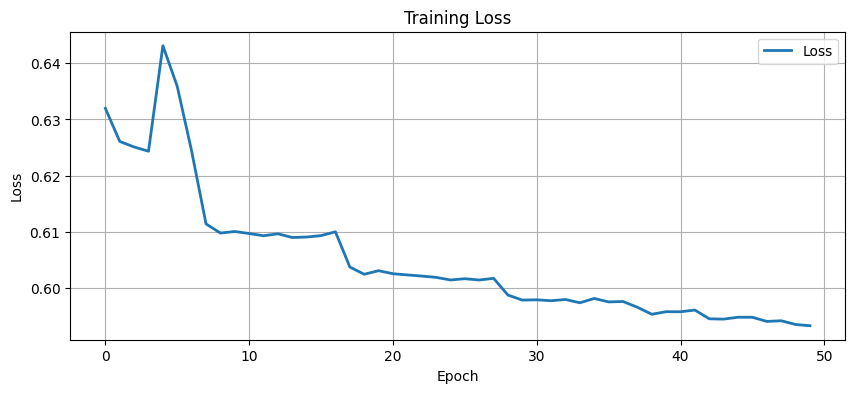

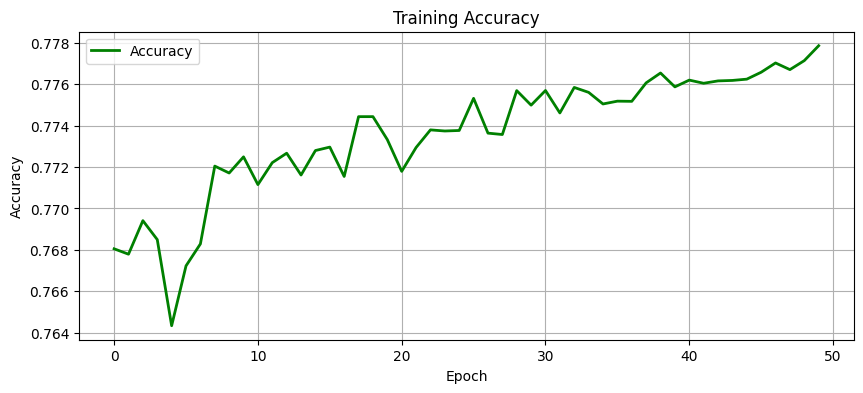

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(loss_history, label="Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(acc_history, label="Accuracy", color="green", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.legend()
plt.show()


## **Generación Avanzada con Temperature, Top-K y Top-P Sampling**
En esta sección mejoraremos la inferencia del modelo PhraseNet-GPT usando técnicas de sampling modernas.

### ¿Por qué usar sampling?
Los modelos autoregresivos tienden a generar siempre las frases más probables.  
Con sampling podemos:

- Controlar la creatividad del modelo.
- Generar frases distintas cada vez.
- Evitar respuestas demasiado repetitivas.
- Permitir variaciones naturales en el lenguaje.

### Parámetros implementados:

**temperature**  
Controla la aleatoriedad.  
- 1.0 → normal  
- >1.0 → más creativo  
- <1.0 → más conservador  

**top-k**  
Limita la selección a los k tokens más probables.  
Ej:
- k=50 funciona muy bien.

**top-p (nucleus sampling)**  
Selección del conjunto mínimo de tokens cuya suma de probabilidad ≥ p.  
- p=0.9 → muy natural  
- p=0.8 → más controlado

El modelo sigue siendo autoregresivo y causal, pero con sampling obtenemos generación mucho más flexible y realista.


In [11]:
import torch
import torch.nn.functional as F

def sample_next_token(logits, temperature=1.0, top_k=50, top_p=0.9):
    logits = logits / temperature

    if top_k is not None:
        indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
        logits[indices_to_remove] = -float('Inf')

    if top_p is not None:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        
        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        indices_to_remove = sorted_indices_to_remove.scatter(dim=1, index=sorted_indices, src=sorted_indices_to_remove)
        logits[indices_to_remove] = -float('Inf')

    probs = F.softmax(logits, dim=-1)
    idx = torch.multinomial(probs, num_samples=1).item()
    return idx

def generate_phrase_sampling(command, max_length=20, temperature=1.0, top_k=50, top_p=0.9):
    model.eval()

    cmd_id = cmd2id[command]
    cmd_tensor = torch.tensor([cmd_id]).cuda()

    tokens = [bos]

    for _ in range(max_length):
        tokens_in = torch.tensor(tokens).unsqueeze(0).cuda()

        with torch.no_grad():
            logits = model(cmd_tensor, tokens_in)[0, -1]

        next_token = sample_next_token(logits, temperature, top_k, top_p)
        tokens.append(next_token)

        if next_token == eos:
            break

    if eos in tokens:
        tokens = tokens[1:tokens.index(eos)]
    else:
        tokens = tokens[1:]

    frase = tokenizer.decode(tokens)
    return frase

# --- Definiciones que debes tener (ejemplos) ---
# model = ...
# tokenizer = ...
# bos = ...
# eos = ...
# cmd2id = {"saludar": 0, "preguntar": 1}
# ------------------------------------------------

cmds = ["saludar", "preguntar"] 

for c in cmds:
    print(c, "→", generate_phrase_sampling(c, temperature=1.1, top_k=40, top_p=0.92))

KeyError: 'saludar'

# **Guardado Completo del Modelo PhraseNet-GPT y Sus Recursos**
En esta sección exportaremos todo lo necesario para usar PhraseNet-GPT en producción.

Este paquete incluirá:

### 1. Modelo entrenado
- Archivo: `PhraseNetGPT_best.pt`
- Contiene todos los pesos del Mini-GPT.

### 2. Tokenizer SentencePiece
- `tok.model`
- `tok.vocab`
- Permite convertir texto ↔ tokens.

### 3. Mapeo de comandos
- `cmd2id.pt`
- `id2cmd.pt`

### 4. Configuración del modelo
- `config.json`
    - dim. de embeddings  
    - número de capas  
    - vocab size  
    - número de comandos  
    - longitud máxima  

Con estos archivos puedes cargar PhraseNet-GPT desde cualquier proyecto (PC, servidor, microservicio, aplicación móvil o módulo IA de SynkroHogar).


In [63]:
import torch
import json

torch.save(model.state_dict(), "PhraseNetGPT_best.pt")
print("Modelo guardado:", "PhraseNetGPT_best.pt")

torch.save(cmd2id, "cmd2id.pt")
torch.save(id2cmd, "id2cmd.pt")
print("Mapeos de comandos guardados.")

config = {
    "emb_dim": model.emb_tok.embedding_dim,
    "layers": len(model.layers),
    "num_heads": model.layers[0].attn.num_heads,
    "ff_dim": model.layers[0].ff[0].out_features,
    "vocab_size": vocab_size,
    "num_cmds": len(cmd2id),
    "max_len": model.max_len
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Configuración guardada en config.json")

print("Tokenizer ya está en tok.model y tok.vocab")


Modelo guardado: PhraseNetGPT_best.pt
Mapeos de comandos guardados.
Configuración guardada en config.json
Tokenizer ya está en tok.model y tok.vocab


In [8]:
import torch
import torch.nn as nn
import json
import os
import sentencepiece as spm

base = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal"

model_path  = os.path.join(base, "PhraseNetGPT_best.pt")
tok_path    = os.path.join(base, "tok.model")
config_path = os.path.join(base, "config.json")
cmd2id_path = os.path.join(base, "cmd2id.pt")
id2cmd_path = os.path.join(base, "id2cmd.pt")

# Cargar config.json
with open(config_path, "r") as f:
    cfg = json.load(f)

emb_dim   = cfg["emb_dim"]
layers_n  = cfg["layers"]
num_heads = cfg["num_heads"]
ff_dim    = cfg["ff_dim"]
vocab_size = cfg["vocab_size"]
num_cmds   = cfg["num_cmds"]
max_len    = cfg["max_len"]

# Tokenizer
sp = spm.SentencePieceProcessor(model_file=tok_path)

# Mapas comando <-> id
cmd2id = torch.load(cmd2id_path)
id2cmd = torch.load(id2cmd_path)

# Bloque GPT real
class GPTBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.ff = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, emb_dim)
        )
        self.norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x

# Arquitectura correcta
class PhraseNetGPT(nn.Module):
    def __init__(self, vocab_size, emb_dim, layers_n, num_heads, ff_dim, num_cmds):
        super().__init__()

        self.emb_tok = nn.Embedding(vocab_size, emb_dim)
        self.emb_cmd = nn.Embedding(num_cmds, emb_dim)

        self.layers = nn.ModuleList([
            GPTBlock(emb_dim, num_heads, ff_dim)
            for _ in range(layers_n)
        ])

        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, tok_ids, cmd_ids):
        tok_emb = self.emb_tok(tok_ids)
        cmd_emb = self.emb_cmd(cmd_ids)  # [B, T] -> [B, T, emb_dim]

        x = tok_emb + cmd_emb

        for layer in self.layers:
            x = layer(x)

        return self.fc(x)

# Instanciar modelo exacto
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PhraseNetGPT(vocab_size, emb_dim, layers_n, num_heads, ff_dim, num_cmds).to(device)

# Cargar pesos exactos
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Modelo PhraseNetGPT_best cargado correctamente.")


Modelo PhraseNetGPT_best cargado correctamente.
